In [1]:
using Accessors
using Gen
using Compose
using PhySMC
using PhyBullet
using PyCall
using Parameters
using DocStringExtensions
using Distributions
using LinearAlgebra
using Random
using Statistics
using Plots

pybullet build time: Oct 21 2025 11:20:22


In [27]:
################################################################################
# Minimal collision-capsule MSC model
################################################################################

Base.@kwdef struct MSCParams
    # Epsilon for numerical stability
    eps::Float64 = 1e-9

    # Collision Birth Features: 
    birth_gap_max::Float64 = 0.10               # Maximum gap for which objects are 'close'
    birth_gap_scale::Float64 = 0.025            # Gap gate parameter 
    birth_v_min::Float64 = 0.02                 # Minimum closing speech for which objects are 'appraching'
    birth_v_scale::Float64 = 0.02               # Closing speed gate parameter 
    birth_T_contact::Float64 = 0.25             # Contact prediction horizon
    birth_tau_scale::Float64 = 0.05             # Time to contact gate parameter
    birth_base::Float64 = 0.99                  # Base probability of collision when all predicates are satisfied

    # Object dimensions 
    obj_dims  = [[0.15, 0.3, 0.075], [0.2,  0.2, 0.1]] # ramp, then table 

    # Collision Death Features 
    min_active_steps::Int = 5                   # minimum steps for capsule to be active
    min_age_survival::Float64 = 1.0             # min survival prob early on
    age_decay_steps::Float64 = 5.0              # gradual decay of survival
    survival_distance_scale::Float64 = 0.45     # scale for near collision
    death_v_min::Float64 = 0.02
    death_v_scale::Float64 = 0.02

    no_birth_weight::Float64 = 0.3              # weight of having no capsule births
end

const DEFAULT_MSC_PARAMS = MSCParams()

# This is the abstract type for a capsule.
abstract type MSC end

# This struct is some diagnostic / functional stats for the entire state
struct MSCEventStats
    n_active::Int
    n_persisted::Int
    n_died::Int
    birth_prob::Float64           # Birth prob of the new capsule; in case of no birth – total prob of any birth
    born::Bool
end

# This is a capsule kind - collision of two objects (by ID)
struct CollisionMSC <: MSC
    a::Int
    b::Int
    age::Int
end

# This is a capsule kind - sliding of one object (by ID) (just an example for now)
struct SlidingMSC <: MSC
    a::Int
    surface::Int
    age::Int
end

# Here we track the state of the entire scene
struct MSCState
    # Vector of all (interacting) objects in the scene as a Bullet State
    objects::BulletState
    # Vector of all active capsules in the scene
    capsules::Vector{MSC}
    # Statistics for diagnostoc / plotting reasons
    event_stats::MSCEventStats
end

# A diff structure for one object, all latents to be updated
struct ObjectDiff
    object_id::Int
    changes::Dict{Symbol, Float64}
end

# A diff structure for all objects in a capsule, all latents to be updated
struct CapsuleDiff
    diffs::Vector{ObjectDiff}
end


#### Helpers to manage capsules ####

# Initializer
function default_msc_event_stats()
    return MSCEventStats(0, 0, 0, 0.0, false)
end

# Initializer
function initial_msc_state(objects::BulletState, params::MSCParams=MSCParams())
    return MSCState(objects, MSC[], default_msc_event_stats())
end

# Helper to calculate collision birth and death probability
function collision_helper(objects::BulletState, a::Int, b::Int, params::MSCParams)
    # Extract kinematic properties from the bullet state
    ka = objects.kinematics[a]
    kb = objects.kinematics[b]

    xa = Vector{Float64}(ka.position)
    xb = Vector{Float64}(kb.position)

    va = Vector{Float64}(ka.linear_vel)
    vb = Vector{Float64}(kb.linear_vel)

    # Relative distance and velocity in 2D 
    offset = xb .- xa
    distance = norm(offset)

    rhat = offset ./ max(distance, params.eps)

    rel_vel = vb .- va

    # Positive means the surface gap is shrinking.
    v_closing = -dot(rel_vel, rhat)

    # Surface Gap using bounding-sphere radii.
    R_ramp  = norm(params.obj_dims[a]) / 2
    R_table = norm(params.obj_dims[b]) / 2
    R_sum = R_ramp + R_table

    gap = distance - R_sum

    # Constant velocity time to contact 
    if gap > 0.0 && v_closing > params.birth_v_min
        tau = gap / v_closing
    else
        tau = NaN               # If the objects are not separated & approaching, tau is meaningless 
    end

    # Sigmoidal scores 
    sigmoid(z) = 1 / (1 + exp(-z))

    p_gap = sigmoid((params.birth_gap_max - gap) / params.birth_gap_scale)
    p_closing = sigmoid((v_closing - params.birth_v_min) / params.birth_v_scale)

    if isnan(tau)
        p_ttc = 0.0
    else
        p_ttc = sigmoid((params.birth_T_contact - tau) / params.birth_tau_scale)
    end

    # Final collision birth probability for this pair.
    birth_prob = params.birth_base * p_gap * p_closing * p_ttc

    # Survival probability 
    near_gap = max(gap, 0.0)
    near_score = exp(-((near_gap / params.survival_distance_scale)^2))

    return (
        distance = distance,
        gap = gap,
        v_closing = v_closing,
        tau = tau,

        p_gap = p_gap,
        p_closing = p_closing,
        p_ttc = p_ttc,

        birth_prob = birth_prob,
        near_score = near_score
    )
end

# Helper to check if a collision capsule is equal to the proposed one
function is_same_collision(cap::MSC, a::Int, b::Int)
    return cap isa CollisionMSC &&
           ((cap.a == a && cap.b == b) || (cap.a == b && cap.b == a))
end

# Helper to check if a collision capsule is already in the given vector
function has_active_collision(capsules::Vector{MSC}, a::Int, b::Int)
    return any(cap -> is_same_collision(cap, a, b), capsules)
end

# Helper to increase the age of a capsule
function increment_age(cap::CollisionMSC)
    return CollisionMSC(cap.a, cap.b, cap.age + 1)
end

# Helper to get all possible capsules that can be activated at a given timem #TODO: Make this sparse! 
function enumerate_collision_birth_candidates(st::MSCState, active_capsules::Vector{MSC}, params::MSCParams)
    candidates = NamedTuple[]

    n_objects = length(st.objects.kinematics)

    for a in 1:(n_objects - 1)
        for b in (a + 1):n_objects
            # Check if this capsule is already active
            if has_active_collision(active_capsules, a, b)
                continue
            end

            # get the distance features 
            features = collision_helper(st.objects, a, b, params)

            # Closer objects get larger birth weight.
            weight = features.birth_prob

            push!(candidates, (
                kind = :collision,
                a = a,
                b = b,
                distance = features.distance,
                weight = weight
            ))
        end
    end

    return candidates
end

# Helper to clamp probability for numerical stability
function _clamp_probability(p::Real)
    return clamp(Float64(p), 1e-4, 1.0 - 1e-4)
end

# Helper to calculate the survival probability for a collision capsule #TODO: Implement a time of life survival predicate 
function collision_survival_probability(st::MSCState, cap::CollisionMSC, params::MSCParams)
    # Get the collision features
    features = collision_helper(st.objects, cap.a, cap.b, params)

    # Check if the minimum number of steps has passed yet 
    if cap.age <= params.min_active_steps
        return params.min_age_survival
    end

    ## Time of Life Component ## 
    age_excess = max(cap.age - params.min_active_steps, 0)
    age_penalty = exp(-age_excess / params.age_decay_steps)

    ## Distance Component ##
    # near_gap = max(features.gap, 0.0)
    # near_score = exp(-((near_gap / params.survival_distance_scale)^2))

    ## Velocity Component 
    # v_separating = -features.v_closing
    # sigmoid(z) = 1 / (1 + exp(-z))
    # p_separating = sigmoid((v_separating - params.death_v_min) / params.death_v_scale)
    # velocity_survival = 1.0 - p_separating

    # Survival prob is e^((-distance/scale)^2)*e^((-age_excess/scale)^2)*(1 - sigmoid((-closing_speed - min_v)/v_scale))
    p = age_penalty # * near_score * velocity_survival

    return p
end

#### GENERATIVE FUNCTIONS ####

# A generative function to track all persisting capsules #TODO: Fix this categorical distribution 
@gen function capsule_persistence(prev::MSCState, params::MSCParams)
    # Track all capsules that survive
    persisted = MSC[]

    # Track the number of capsules that died
    n_died = 0

    # Loop over all capsules in the previous state
    for (i, cap) in enumerate(prev.capsules)
        if cap isa CollisionMSC
            # Calculate survival probability
            p_survive = collision_survival_probability(prev, cap, params)

            # Sample whether this capsule survives with bernoulli
            survived = {:survived => i} ~ bernoulli(p_survive)

            # If it survived, increment age. Else, kill.
            if Bool(survived)
                push!(persisted, increment_age(cap))
            else
                n_died += 1
            end
        else
            # Placeholder until others are made
            error("Unknown capsule type: $(typeof(cap))")
        end
    end

    return (
        capsules = persisted,
        n_died = n_died
    )
end

# A generative function to sample new capsules (at most one)
@gen function sample_new_capsule(prev::MSCState, persisted_capsules::Vector{MSC}, params::MSCParams)

    # Get all possible collision candidates for this scene
    candidates = enumerate_collision_birth_candidates(prev, persisted_capsules, params)

    # Case: no possible new capsule.
    if isempty(candidates)
        return (
            born = false,
            capsule = nothing,
            birth_prob = 0.0
        )
    end

    # Add an option for no births
    weights = [params.no_birth_weight; [c.weight for c in candidates]]
    probs = weights ./ sum(weights)

    choice ~ categorical(probs)

    # choice == 1 means no birth.
    if choice == 1
        return (
            born = false,
            capsule = nothing,
            birth_prob = 1.0 - probs[1]
        )
    end

    candidate = candidates[choice - 1]

    new_capsule = CollisionMSC(candidate.a, candidate.b, 1)

    return (
        born = true,
        capsule = new_capsule,
        birth_prob = probs[choice]
    )
end

# A generative function to combine capsule birth, persistence, and death
@gen function capsule_kernel(prev::MSCState, params::MSCParams)
    persisted_result ~ capsule_persistence(prev, params)

    birth_result ~ sample_new_capsule(prev, persisted_result.capsules, params)

    capsules = copy(persisted_result.capsules)

    if birth_result.born
        push!(capsules, birth_result.capsule)
    end

    stats = MSCEventStats(
        length(capsules),
        length(persisted_result.capsules),
        persisted_result.n_died,
        birth_result.birth_prob,
        birth_result.born
    )

    return (
        capsules = capsules,
        stats = stats
    )
end

# A generative function that does the capsule step and physics update (normal for now)
@gen function msc_physics_step(t::Int, prev::MSCState, sim::BulletSim, params::MSCParams)

    capsule_update ~ capsule_kernel(prev, params)

    # For now: capsules only track event structure.
    # Later: active capsules will produce diffs before this step.
    next_objects = PhySMC.step(sim, prev.objects)

    positions ~ Gen.Map(observe)(next_objects.kinematics)

    return MSCState(
        next_objects,
        capsule_update.capsules,
        capsule_update.stats
    )
end

# Complete MSC model code
@gen function msc_model(T::Int, sim::BulletSim, template::BulletState, params::MSCParams)
    # Sample latents from the prior
    latents ~ prior(template.latents)

    # Set a template for initial scene
    init_objects = Accessors.setproperties(template; latents=latents)

    # Initial state
    init_state = initial_msc_state(init_objects, params)

    # Final physics and likelihood
    states ~ Gen.Unfold(msc_physics_step)(T, init_state, sim, params)

    return states
end

################################################################################
# Rejuvenation proposal for MSC v0
################################################################################

@gen function msc_proposal(tr::Gen.Trace)
    choices = get_choices(tr)
    prev_mass = choices[:latents => :obj1 => :mass]
    mass = {:latents => :obj1 => :mass} ~ trunc_norm(prev_mass, 1.0, 0.0, Inf)
    return mass
end

################################################################################
# Sequential inference with stored history
################################################################################

function msc_inference_procedure(gm_args::Tuple,
                                 obs::Vector{Gen.ChoiceMap},
                                 particles::Int=20,
                                 rejuv_moves::Int=1)

    get_args(t) = (t, gm_args[2:4]...)
    state = Gen.initialize_particle_filter(msc_model, get_args(0), EmptyChoiceMap(), particles)
    argdiffs = (UnknownChange(), NoChange(), NoChange(), NoChange())

    for (t, o) in enumerate(obs)
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)
        Gen.maybe_resample!(state, ess_threshold=particles / 2)

        for i in 1:particles, s in 1:rejuv_moves
            state.traces[i], _ = Gen.mh(state.traces[i], msc_proposal, ())
        end
    end

    return Gen.sample_unweighted_traces(state, particles)
end

function extract_msc_capsules(tr::Gen.Trace, t::Int)
    return get_retval(tr)[t].capsules
end

function extract_msc_event_stats(tr::Gen.Trace, t::Int)
    return get_retval(tr)[t].event_stats
end

function _mean_active_capsule_age(capsules::Vector{MSC})
    isempty(capsules) && return 0.0
    return mean(Float64[cap.age for cap in capsules])
end

function summarize_msc_capsules(traces, t::Int)
    capsules_by_trace = [extract_msc_capsules(tr, t) for tr in traces]
    event_stats = [extract_msc_event_stats(tr, t) for tr in traces]
    active_counts = [length(capsules) for capsules in capsules_by_trace]
    active = active_counts .> 0

    birth_events = [stats.born for stats in event_stats]
    death_counts = [stats.n_died for stats in event_stats]
    death_events = death_counts .> 0
    switch_events = birth_events .| death_events

    return (
        capsule_active_prob = mean(Float64.(active)),
        capsule_switch_prob = mean(Float64.(switch_events)),
        capsule_birth_prob = mean(Float64.(birth_events)),
        capsule_death_prob = mean(Float64.(death_events)),
        capsule_mean_active_count = mean(Float64.(active_counts)),
        capsule_mean_death_count = mean(Float64.(death_counts)),
        capsule_mean_age = mean(Float64[_mean_active_capsule_age(capsules) for capsules in capsules_by_trace]),
        capsule_mean_birth_probability = mean(Float64[stats.birth_prob for stats in event_stats])
    )
end

function msc_inference_with_history(gm_args::Tuple,
                                    obs::Vector{Gen.ChoiceMap},
                                    particles::Int=20,
                                    rejuv_moves::Int=1)

    get_args(t) = (t, gm_args[2:4]...)
    state = Gen.initialize_particle_filter(msc_model, get_args(0), EmptyChoiceMap(), particles)
    argdiffs = (UnknownChange(), NoChange(), NoChange(), NoChange())

    history = Vector{NamedTuple}(undef, length(obs))

    for (t, o) in enumerate(obs)
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)
        Gen.maybe_resample!(state, ess_threshold=particles / 2)

        for i in 1:particles, s in 1:rejuv_moves
            state.traces[i], _ = Gen.mh(state.traces[i], msc_proposal, ())
        end

        current_traces = Gen.sample_unweighted_traces(state, particles)
        mass_summary = summarize_trace_set(current_traces)
        capsule_summary = summarize_msc_capsules(current_traces, t)

        history[t] = (
            t = t,
            mean = mass_summary.mean,
            std = mass_summary.std,
            q05 = mass_summary.q05,
            q25 = mass_summary.q25,
            q75 = mass_summary.q75,
            q95 = mass_summary.q95,
            capsule_active_prob = capsule_summary.capsule_active_prob,
            capsule_switch_prob = capsule_summary.capsule_switch_prob,
            capsule_birth_prob = capsule_summary.capsule_birth_prob,
            capsule_death_prob = capsule_summary.capsule_death_prob,
            capsule_mean_active_count = capsule_summary.capsule_mean_active_count,
            capsule_mean_death_count = capsule_summary.capsule_mean_death_count,
            capsule_mean_age = capsule_summary.capsule_mean_age,
            capsule_mean_birth_probability = capsule_summary.capsule_mean_birth_probability,
            traces = current_traces
        )
    end

    return history
end

################################################################################
# Synthetic smoke test and timing spec
################################################################################

function run_msc_smoke_test(T::Int, sim, template, params::MSCParams=DEFAULT_MSC_PARAMS;
                            particles=30,
                            rejuv_moves=2,
                            ground_truth_mass=nothing)
    true_mass = ground_truth_mass === nothing ? template_mass_ratio(template) : Float64(ground_truth_mass)
    true_trace, = Gen.generate(msc_model, (T, sim, template, params), mass_constraint(true_mass))
    observed_positions = observations_from_trace(true_trace)
    obs = make_observations(observed_positions)

    history = msc_inference_with_history((T, sim, template, params), obs, particles, rejuv_moves)
    collision_time = detect_collision_time(observed_positions)

    return (
        true_trace = true_trace,
        ground_truth_mass = true_mass,
        observed_positions = observed_positions,
        obs = obs,
        history = history,
        collision_time = collision_time
    )
end

function msc_timing_spec(; label="MSC v0", params::MSCParams=DEFAULT_MSC_PARAMS)
    return make_pf_timing_spec(
        label = label,
        pf_model = msc_model,
        gm_args_builder = (T, sim, template) -> (T, sim, template, params),
        online_args = gm_args -> (t -> (t, gm_args[2:4]...)),
        argdiffs = (UnknownChange(), NoChange(), NoChange(), NoChange()),
        rejuvenate! = function (state, t, particles, rejuv_moves)
            for i in 1:particles, s in 1:rejuv_moves
                state.traces[i], _ = Gen.mh(state.traces[i], msc_proposal, ())
            end
            return nothing
        end
    )
end;

In [28]:
function ramp(mass_ratio::Float64, obj_frictions::NTuple{2, Float64} = (.5, .5), obj_positions::NTuple{2, Float64} = (0.5, 1.5), slope::Float64=2/3, tableRampIntersection::Float64=0.0)
    
    # for debugging
    #client = @pycall pb.connect(pb.GUI)::Int64
    #pb.resetDebugVisualizerCamera(4.5, 0, -40, [0.0, 0.0, 0.0]; physicsClientId=client)

    # Set up the pybullet client and set gravity at -10
    client = @pycall pb.connect(pb.DIRECT)::Int64
    pb.setGravity(0,0,-10; physicsClientId = client)


    # add a table base (setting mass = 0 makes it a static object)
    grey = [0.5, 0.5, 0.5, 1]
    base_dims = [5, 1, 0.75] # in meters
    table_dims = [base_dims[1] + 0.2, base_dims[2] + 0.2, 0.1]  # Width, depth, height
    table_base_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents = base_dims / 2, physicsClientId = client)
    table_base_obj_id = pb.createMultiBody(baseCollisionShapeIndex = table_base_col_id, basePosition = [0,0,-(base_dims[3]+table_dims[3])/2], physicsClientId = client)
    pb.changeDynamics(table_base_obj_id, -1; mass = 0., restitution = 0.9, physicsClientId=client)
    pb.changeVisualShape(table_base_obj_id, -1, rgbaColor=grey, physicsClientId=client)

    # Create the tabletop (a flat box)
    table_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=table_dims/2)
    table_body_id = pb.createMultiBody(baseCollisionShapeIndex=table_col_id, basePosition=[0, 0, -table_dims[3]/2])
    pb.changeDynamics(table_body_id, -1; mass = 0., restitution = 0.9, physicsClientId=client)
    pb.changeVisualShape(table_body_id, -1, rgbaColor=grey.+0.2, physicsClientId=client)

    # Create the four frame-like boxes around the tabletop
    frame_height = 0.25
    frame_thickness = 0.05

    frame_dims = [
        [table_dims[1] + 2 * frame_thickness, frame_thickness, frame_height],  # Longer sides
        [table_dims[1] + 2 * frame_thickness, frame_thickness, frame_height],  # Longer sides
        [frame_thickness, table_dims[2], frame_height],  # Shorter sides
        [frame_thickness, table_dims[2], frame_height]  # Shorter sides
    ]

    frame_positions = [
        [0, table_dims[2] / 2 + frame_thickness / 2, 0],  # Top side
        [0, -table_dims[2] / 2 - frame_thickness / 2, 0],  # Bottom side
        [table_dims[1] / 2 + frame_thickness / 2, 0, 0],  # Right side
        [-table_dims[1] / 2 - frame_thickness / 2, 0, 0]  # Left side
    ]

    for (dims, pos) in zip(frame_dims, frame_positions)
        frame_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=dims/2)::Int64
        frame_obj_id = pb.createMultiBody(baseCollisionShapeIndex=frame_col_id, basePosition=pos)::Int64
        pb.changeVisualShape(frame_obj_id, -1, rgbaColor=grey, physicsClientId=client)
    end

    # add a ramp
    pb.setAdditionalSearchPath("/gpfs/radev/project/yildirim/aa2842/minimum-simulation-capsules")
    ramp_col_id = pb.createCollisionShape(pb.GEOM_MESH, fileName="/assets/ramp.obj", physicsClientId=client, meshScale=[2, base_dims[2], slope*2])
    ramp_position = [-2+tableRampIntersection, -base_dims[2]/2, 0]
    ramp_obj_id = pb.createMultiBody(baseCollisionShapeIndex=ramp_col_id, basePosition=ramp_position, physicsClientId=client)
    pb.changeDynamics(ramp_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)
    pb.changeVisualShape(ramp_obj_id, -1, rgbaColor=[1, 1, 1, 1], physicsClientId=client)

    # add a floor
    floor_col_id = pb.createCollisionShape(pb.GEOM_PLANE, physicsClientId=client)
    floor_obj_id = pb.createMultiBody(baseCollisionShapeIndex=floor_col_id, basePosition=[0,0,-base_dims[3]], physicsClientId=client)
    pb.changeDynamics(floor_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)


    #  add walls
    wall_dims = [[0.1, 8.0, 5.0], [0.1, 8.0, 5.0], [8.0, 0.1, 5.0]] # Width, length, height
    wall_positions = [
        [4.0, 0.0, 1.0],  # Right Wall
        [-4.0, 0.0, 1.0],  # Left Wall
        [0, 4, wall_dims[3][3]/2-base_dims[3]] # Back Wall
    ]
    for (dims, pos) in zip(wall_dims, wall_positions)
        wall_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=dims./2, physicsClientId=client)
        wall_obj_id = pb.createMultiBody(baseCollisionShapeIndex=wall_col_id, basePosition=pos, physicsClientId=client)
        pb.changeDynamics(wall_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)
        pb.changeVisualShape(wall_obj_id, -1, rgbaColor=grey+[0.2, 0.2, 0.2, 0], physicsClientId=client)
    end

    # add an object on the ramp
    obj_ramp_dims = [0.15, 0.3, 0.075]
    theta_radians = -atan(slope)
    orientation = [cos(theta_radians / 2), 0, sin(theta_radians / 2), 0]

    obj_on_ramp_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=obj_ramp_dims/2, physicsClientId=client)
    lift = obj_ramp_dims[3]/2
    position = [
        -2+2*obj_positions[1]+tableRampIntersection+lift*cos(theta_radians),
        0,
        (2-2*obj_positions[1])*slope-lift*sin(theta_radians)
    ]
    obj_on_ramp_obj_id = pb.createMultiBody(baseCollisionShapeIndex=obj_on_ramp_col_id, basePosition=position, baseOrientation=orientation, physicsClientId=client)
    pb.changeDynamics(obj_on_ramp_obj_id, -1; mass=mass_ratio, restitution=0.9, lateralFriction=obj_frictions[1], physicsClientId=client)
    
    # add an object on the table that will collide with the object on the ramp as that one slides down
    obj_on_table_dims = [0.2, 0.2, 0.1]
    obj_on_table_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=obj_on_table_dims/2, physicsClientId=client)
    obj_on_table_obj_id = pb.createMultiBody(baseCollisionShapeIndex=obj_on_table_col_id, basePosition=[2.5*(obj_positions[2]-1), 0, obj_on_table_dims[3]/2], physicsClientId=client)
    pb.changeDynamics(obj_on_table_obj_id, -1; mass=1.0, restitution=0.9, lateralFriction=obj_frictions[2], physicsClientId=client)

    (client, obj_on_ramp_obj_id, obj_on_table_obj_id)
end

ramp (generic function with 5 methods)

In [29]:
# Declare constants and create a scene
mass_ratio = 15.0
obj_frictions = (0.3, 0.3)
obj_positions = (0.5, 1.5)

client, obj_1, obj_2 = ramp(mass_ratio, obj_frictions, obj_positions)

(1, 6, 7)

In [30]:
# create PhySMC and PhyBullet objects
sim = BulletSim(; client=client)
obj_r = RigidBody(obj_1)           # ramp obj
obj_t = RigidBody(obj_2)           # table obj

# get an initial state (to be overwritten in the prior function)
init_state = BulletState(sim, [obj_r, obj_t]);

In [31]:
params = MSCParams();

In [32]:
# Number of simulation steps to inspect
T = 120

# Use your existing params, or uncomment this:
# params = MSCParams()

states = Vector{Any}(undef, T + 1)
states[1] = init_state

for t in 1:T
    states[t + 1] = PhySMC.step(sim, states[t])
end

ts = collect(0:T);

In [33]:
gap_hist = zeros(T + 1)
v_closing_hist = zeros(T + 1)
v_separating_hist = zeros(T + 1)
near_score_hist = zeros(T + 1)
collision_hist = falses(T + 1)

for idx in eachindex(states)
    state = states[idx]

    features = collision_helper(state, 1, 2, params)

    gap_hist[idx] = features.gap
    v_closing_hist[idx] = features.v_closing
    v_separating_hist[idx] = -features.v_closing
    near_score_hist[idx] = features.near_score

    # Approximate collision detection using your same bounding-sphere gap
    collision_hist[idx] = features.gap <= 0.0
end

collision_indices = findall(collision_hist)

collision_idx = isempty(collision_indices) ? nothing : first(collision_indices)
collision_t = collision_idx === nothing ? nothing : ts[collision_idx]

println("Estimated collision time = ", collision_t)

Estimated collision time = 58


In [17]:
age_hist = fill(NaN, T + 1)
age_penalty_hist = fill(NaN, T + 1)
survival_prob_hist = fill(NaN, T + 1)

if collision_idx !== nothing
    for idx in collision_idx:length(states)
        t = ts[idx]

        # Pretend the collision capsule is born at collision_t
        age = t - collision_t
        age_hist[idx] = age

        # This now matches your current collision_survival_probability function
        if age <= params.min_active_steps
            survival_prob = params.min_age_survival
            age_penalty = params.min_age_survival
        else
            age_excess = max(age - params.min_active_steps, 0)
            age_penalty = exp(-age_excess / params.age_decay_steps)
            survival_prob = age_penalty
        end

        age_penalty_hist[idx] = age_penalty
        survival_prob_hist[idx] = survival_prob
    end
end

println("Survival probability near collision:")
if collision_idx !== nothing
    lo = max(collision_idx - 3, 1)
    hi = min(collision_idx + 15, length(ts))

    for i in lo:hi
        println((
            t = ts[i],
            age = age_hist[i],
            gap = gap_hist[i],
            v_closing = v_closing_hist[i],
            near_score = near_score_hist[i],
            age_penalty = age_penalty_hist[i],
            velocity_survival = velocity_survival_hist[i],
            survival_prob = survival_prob_hist[i]
        ))
    end
end;

Survival probability near collision:
(t = 57, age = NaN, gap = 0.06806446783324416, v_closing = 1.5397790848473856, near_score = 0.9773818291356237, age_penalty = NaN, velocity_survival = NaN, survival_prob = NaN)
(t = 58, age = NaN, gap = 0.035808070130259884, v_closing = 1.5544196122821452, near_score = 0.9936880643085259, age_penalty = NaN, velocity_survival = NaN, survival_prob = NaN)
(t = 59, age = NaN, gap = 0.0032671789782915406, v_closing = 1.5519149052136085, near_score = 0.9999472880141345, age_penalty = NaN, velocity_survival = NaN, survival_prob = NaN)
(t = 60, age = 0.0, gap = -0.029335867181906783, v_closing = 1.5734575919274192, near_score = 1.0, age_penalty = 1.0, velocity_survival = 1.0, survival_prob = 1.0)
(t = 61, age = 1.0, gap = -0.06233592069432242, v_closing = 1.5884266234086453, near_score = 1.0, age_penalty = 1.0, velocity_survival = 1.0, survival_prob = 1.0)
(t = 62, age = 2.0, gap = -0.06849834038639563, v_closing = -0.04151807523852519, near_score = 1.0, ag

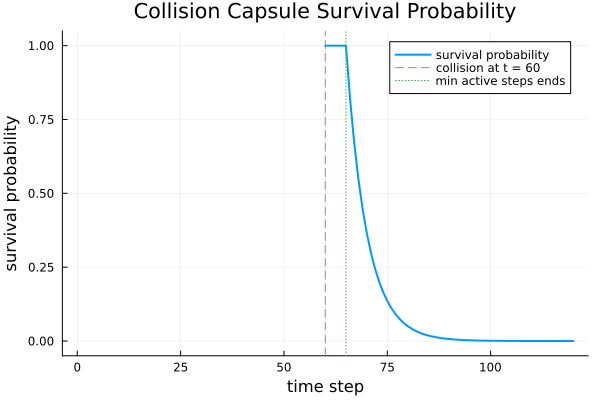

In [18]:
collision_label = collision_t === nothing ? "no collision detected" : "collision at t = $collision_t"

plt_survival = plot(
    ts,
    survival_prob_hist,
    xlabel = "time step",
    ylabel = "survival probability",
    title = "Collision Capsule Survival Probability",
    label = "survival probability",
    linewidth = 2,
    ylim = (-0.05, 1.05),
    legend = :topright
)

if collision_t !== nothing
    vline!(plt_survival, [collision_t], label = collision_label, linestyle = :dash)
    vline!(plt_survival, [collision_t + params.min_active_steps],
           label = "min active steps ends", linestyle = :dot)
end

display(plt_survival)

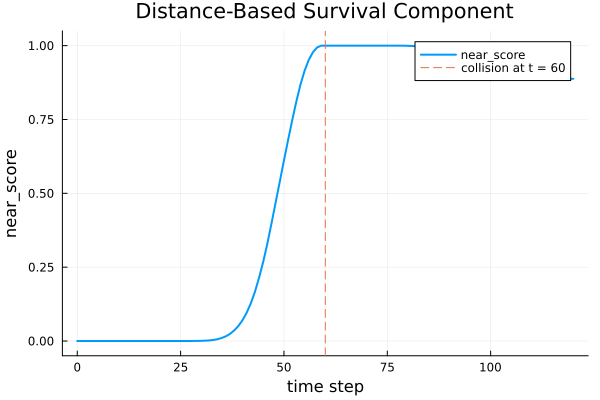

In [19]:
plt_near = plot(
    ts,
    near_score_hist,
    xlabel = "time step",
    ylabel = "near_score",
    title = "Distance-Based Survival Component",
    label = "near_score",
    linewidth = 2,
    ylim = (-0.05, 1.05),
    legend = :topright
)

if collision_t !== nothing
    vline!(plt_near, [collision_t], label = collision_label, linestyle = :dash)
end

display(plt_near)

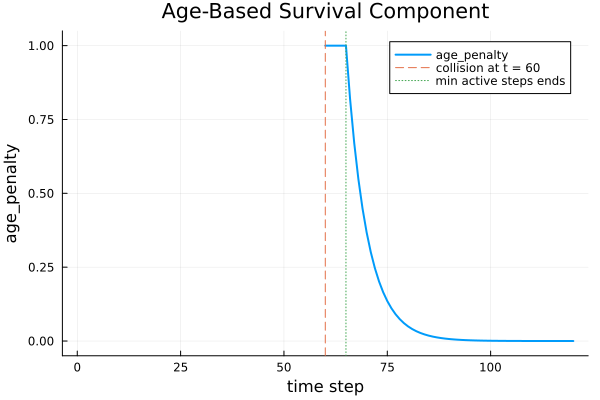

In [20]:
plt_age = plot(
    ts,
    age_penalty_hist,
    xlabel = "time step",
    ylabel = "age_penalty",
    title = "Age-Based Survival Component",
    label = "age_penalty",
    linewidth = 2,
    ylim = (-0.05, 1.05),
    legend = :topright
)

if collision_t !== nothing
    vline!(plt_age, [collision_t], label = collision_label, linestyle = :dash)
    vline!(plt_age, [collision_t + params.min_active_steps],
           label = "min active steps ends", linestyle = :dot)
end

display(plt_age)

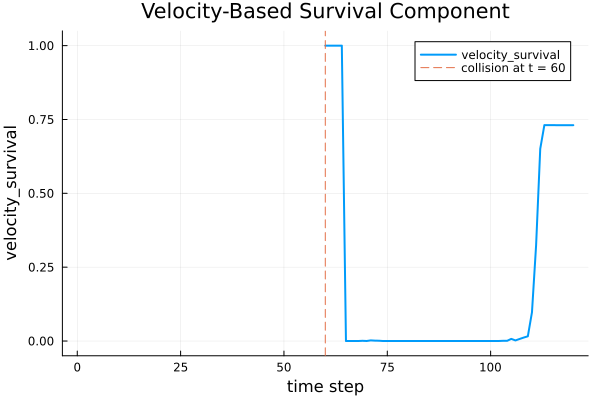

In [21]:
plt_vel = plot(
    ts,
    velocity_survival_hist,
    xlabel = "time step",
    ylabel = "velocity_survival",
    title = "Velocity-Based Survival Component",
    label = "velocity_survival",
    linewidth = 2,
    ylim = (-0.05, 1.05),
    legend = :topright
)

if collision_t !== nothing
    vline!(plt_vel, [collision_t], label = collision_label, linestyle = :dash)
end

display(plt_vel)

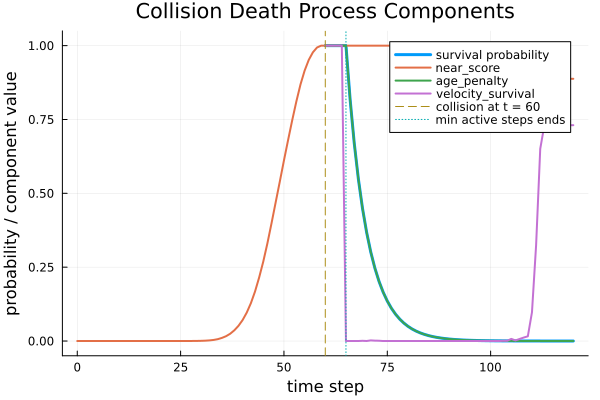

In [22]:
plt_combined = plot(
    ts,
    survival_prob_hist,
    xlabel = "time step",
    ylabel = "probability / component value",
    title = "Collision Death Process Components",
    label = "survival probability",
    linewidth = 3,
    ylim = (-0.05, 1.05),
    legend = :topright
)

plot!(plt_combined, ts, near_score_hist, label = "near_score", linewidth = 2)
plot!(plt_combined, ts, age_penalty_hist, label = "age_penalty", linewidth = 2)
plot!(plt_combined, ts, velocity_survival_hist, label = "velocity_survival", linewidth = 2)

if collision_t !== nothing
    vline!(plt_combined, [collision_t], label = collision_label, linestyle = :dash)
    vline!(plt_combined, [collision_t + params.min_active_steps],
           label = "min active steps ends", linestyle = :dot)
end

display(plt_combined)

# Bounding Box Distance:

In [34]:
# Calculate a quick bounding box distance between objects 
function bounding_box_distance(aabb_a, aabb_b)
    a_min, a_max = aabb_a
    b_min, b_max = aabb_b
    sep_sq = 0.0

    for i in 1:3
        sep = max(a_min[i] - b_max[i], b_min[i] - a_max[i], 0.0)
        sep_sq += sep^2
    end

    return sqrt(sep_sq)
end

bounding_box_distance (generic function with 1 method)

In [35]:
# Reset / re-create the rollout so the AABBs match the trajectory
states_bb = Vector{Any}(undef, T + 1)
states_bb[1] = init_state

bb_dist_hist = zeros(T + 1)

# Get AABB distance at t = 0
aabb_1 = pb.getAABB(obj_1; physicsClientId=client)
aabb_2 = pb.getAABB(obj_2; physicsClientId=client)
bb_dist_hist[1] = bounding_box_distance(aabb_1, aabb_2)

for t in 1:T
    states_bb[t + 1] = PhySMC.step(sim, states_bb[t])

    aabb_1 = pb.getAABB(obj_1; physicsClientId=client)
    aabb_2 = pb.getAABB(obj_2; physicsClientId=client)

    bb_dist_hist[t + 1] = bounding_box_distance(aabb_1, aabb_2)
end

println("Minimum bounding-box distance = ", minimum(bb_dist_hist))

Minimum bounding-box distance = 0.0


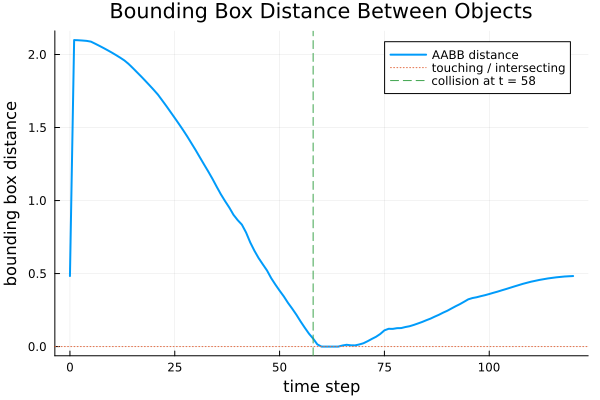

In [36]:
# Fallback if collision_t does not already exist
if !(@isdefined collision_t)
    collision_indices = findall(bb_dist_hist .<= 0.0)
    collision_t = isempty(collision_indices) ? nothing : ts[first(collision_indices)]
end

collision_label = collision_t === nothing ? "no collision detected" : "collision at t = $collision_t"

plt_bb = plot(
    ts,
    bb_dist_hist,
    xlabel = "time step",
    ylabel = "bounding box distance",
    title = "Bounding Box Distance Between Objects",
    label = "AABB distance",
    linewidth = 2,
    legend = :topright
)

hline!(plt_bb, [0.0], label = "touching / intersecting", linestyle = :dot)

if collision_t !== nothing
    vline!(plt_bb, [collision_t], label = collision_label, linestyle = :dash)
end

display(plt_bb)